# 交错 DID 教程

### 从双向固定效应到 Callaway-Sant'Anna

政策很少在同一天对所有地区生效。各省分批试点、各州先后立法，这类**交错处理**（staggered adoption）是应用研究里最常见的 DID 场景。过去的标准做法是跑一个双向固定效应（TWFE）回归，读处理变量的系数。2018 年以来的一批论文指出，只要处理效应随时间或组别变化，这个系数就可能严重偏离真实的平均处理效应，甚至符号相反。

本教程先在一份**真值已知**的模拟数据上把问题演示出来，再换到随包自带的最低工资数据上走一遍完整流程。全程离线，只需要 `import statspai as sp`。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 2×2 DID 与平行趋势 | DID 到底识别什么 |
| 2 | 一份真值已知的交错面板 | 怎么造一个能检验估计量的数据 |
| 3 | TWFE 的答案 | 它离真值有多远 |
| 4 | Bacon 分解 | TWFE 系数是哪些 2×2 比较的加权平均，哪些比较是有问题的 |
| 5 | Callaway-Sant'Anna | 组别-时期 ATT 的思路，四种汇总方式 |
| 6 | 事件研究图 | 逐点区间和同时置信带的区别 |
| 7 | 真实数据走一遍 | 最低工资与青少年就业 |
| 8 | 换几个估计量 | Sun-Abraham、插补法、扩展 TWFE、两阶段 DID |
| 9 | 平行趋势的敏感性分析 | 事前趋势检验通过之后还该做什么 |
| 10 | 小结 | 一份可以照着做的清单 |

## 1. 2×2 DID 与平行趋势

最简单的 DID 只有两组、两期。处理组在第二期接受处理，对照组始终没有。估计量是

$$
\hat\tau_{DID} = \big(\bar Y_{\text{处理},\,\text{后}} - \bar Y_{\text{处理},\,\text{前}}\big) - \big(\bar Y_{\text{对照},\,\text{后}} - \bar Y_{\text{对照},\,\text{前}}\big).
$$

它识别的是处理组的平均处理效应（ATT），前提是**平行趋势**假设成立。

$$
E\big[Y_{后}(0) - Y_{前}(0) \mid \text{处理组}\big] = E\big[Y_{后}(0) - Y_{前}(0) \mid \text{对照组}\big].
$$

用文字说，如果没有政策，处理组的结果变量会和对照组走出同样的变化量。注意这个假设说的是**未处理状态下**的潜在结果，处理组在处理之后的 $Y(0)$ 永远观测不到，所以它无法被直接检验。

交错处理把这个简单结构变复杂了。每个单位有自己的首次处理时点，同一个单位在早期是「尚未处理」，后来变成「已处理」。于是「谁是谁的对照组」不再显而易见。TWFE 回归会替你做出选择，问题在于它的选择未必是你想要的。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 一份真值已知的交错面板

检验一个估计量最直接的办法，是在自己造的数据上看它能不能找回真值。下面生成 300 个单位、10 期的平衡面板。

- 每个单位以 20% 的概率从未被处理，以 40% 的概率在第 4 期开始，以 40% 的概率在第 7 期开始。
- 未处理状态下的结果是「个体效应 + 共同时间趋势 + 噪声」，平行趋势严格成立。
- 处理效应**随处理时长增长**。刚被处理时效应为 1，此后每多一期增加 0.5。

最后一条是关键。效应是动态的，这在现实里再常见不过，政策效果往往需要时间才能显现。

In [2]:
rng = np.random.default_rng(2024)
N, T = 300, 10

# 每个单位的首次处理时点。0 表示从未处理
first = rng.choice([0, 4, 7], size=N, p=[0.2, 0.4, 0.4])
alpha = rng.normal(0, 1, N)  # 个体固定效应

sim = pd.DataFrame(
    {"id": np.repeat(np.arange(N), T), "t": np.tile(np.arange(1, T + 1), N)}
)
sim["g"] = first[sim["id"]]
sim["d"] = ((sim["g"] > 0) & (sim["t"] >= sim["g"])).astype(int)  # 当期是否已处理
sim["e"] = np.where(sim["g"] > 0, sim["t"] - sim["g"], np.nan)    # 相对处理时点的期数

# 真实处理效应：处理当期为 1，之后每期增加 0.5
sim["tau"] = np.where(sim["d"] == 1, 1.0 + 0.5 * sim["e"], 0.0)
sim["y"] = alpha[sim["id"]] + 0.2 * sim["t"] + sim["tau"] + rng.normal(0, 0.5, len(sim))

true_att = sim.loc[sim["d"] == 1, "tau"].mean()
print("各组单位数:")
print(sim.groupby("g")["id"].nunique().rename("n_units").to_string())
print(f"\n真实 ATT（所有已处理观测的平均效应）: {true_att:.3f}")

各组单位数:
g
0     64
4    128
7    108

真实 ATT（所有已处理观测的平均效应）: 2.256


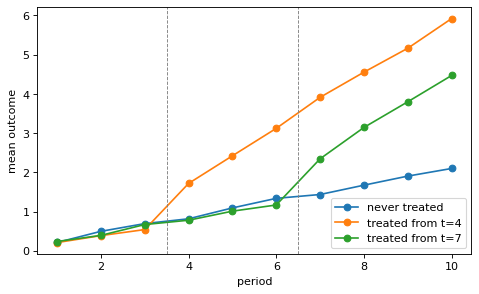

In [3]:
# 三组的平均结果随时间的走势。虚线是各组的首次处理时点
fig, ax = plt.subplots(figsize=(7, 4))
labels = {0: "never treated", 4: "treated from t=4", 7: "treated from t=7"}
for g, grp in sim.groupby("g"):
    ax.plot(grp.groupby("t")["y"].mean(), marker="o", label=labels[g])
for g in (4, 7):
    ax.axvline(g - 0.5, color="grey", ls="--", lw=0.8)
ax.set_xlabel("period")
ax.set_ylabel("mean outcome")
ax.legend()
plt.show()

处理开始之前，三条线基本平行。处理之后，处理组的线向上偏离，并且偏离得越来越多。

## 3. TWFE 的答案

标准的双向固定效应回归是

$$
Y_{it} = \alpha_i + \lambda_t + \beta\, D_{it} + \varepsilon_{it}.
$$

`sp.hdfe_ols` 用竖线分隔回归方程和要吸收的固定效应，相当于 Stata 的 `reghdfe y d, absorb(id t) vce(cluster id)`。

In [4]:
twfe = sp.hdfe_ols("y ~ d | id + t", data=sim, cluster="id")

print(f"TWFE 系数 : {twfe.params['d']:.3f}  (se {twfe.std_errors['d']:.3f})")
print(f"真实 ATT  : {true_att:.3f}")
print(f"偏差      : {twfe.params['d'] - true_att:+.3f}")

TWFE 系数 : 1.415  (se 0.063)
真实 ATT  : 2.256
偏差      : -0.841


TWFE 给出的数字比真值低了三分之一以上，而它的标准误很小，置信区间离真值很远。数据里没有任何遗漏变量，平行趋势也严格成立。问题完全出在估计量本身。

## 4. Bacon 分解

Goodman-Bacon (2021) 证明，交错处理下的 TWFE 系数等于所有可能的 2×2 DID 的加权平均。这些 2×2 比较分三类。

1. **处理组对从未处理组**。干净的比较。
2. **早处理组对晚处理组**，用晚处理组还没被处理的那段时间当对照。也是干净的。
3. **晚处理组对早处理组**，用**已经被处理**的早处理组当对照。这类比较有问题。

第三类为什么有问题？对照组此时已经在处理状态里。如果它的处理效应还在继续增长，这部分增长会被当成「对照组的趋势」从晚处理组的变化里减掉。效应越是动态，减掉的越多。

In [5]:
bacon = sp.bacon_decomposition(sim, y="y", treat="d", time="t", id="id")

print(bacon["decomposition"].round(3).to_string(index=False))
print(f"\n各项加权求和 : {bacon['weighted_sum']:.3f}   (TWFE 系数 {bacon['beta_twfe']:.3f})")
print(f"以已处理单位为对照的比较所占权重 : {bacon['already_treated_control_weight_share']:.1%}")

                    type  treated control  estimate  weight
Later vs Earlier Treated      7.0     4.0    -0.014   0.264
Earlier vs Later Treated      4.0     7.0     1.488   0.198
    Treated vs Untreated      4.0   Never     2.438   0.274
    Treated vs Untreated      7.0   Never     1.727   0.264

各项加权求和 : 1.415   (TWFE 系数 1.415)
以已处理单位为对照的比较所占权重 : 26.4%


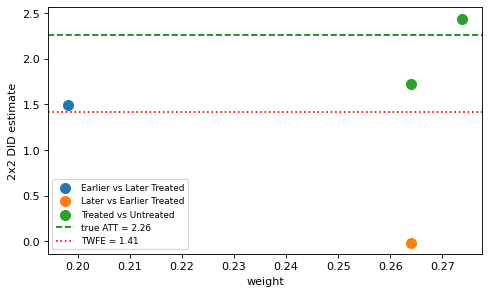

In [6]:
# 把每个 2×2 比较画出来。横轴是权重，纵轴是该比较的估计值
dec = bacon["decomposition"]
fig, ax = plt.subplots(figsize=(7, 4))
for kind, grp in dec.groupby("type"):
    ax.scatter(grp["weight"], grp["estimate"], s=80, label=kind)
ax.axhline(true_att, color="green", ls="--", label=f"true ATT = {true_att:.2f}")
ax.axhline(bacon["beta_twfe"], color="red", ls=":", label=f"TWFE = {bacon['beta_twfe']:.2f}")
ax.set_xlabel("weight")
ax.set_ylabel("2x2 DID estimate")
ax.legend(fontsize=8)
plt.show()

「Later vs Earlier Treated」那一行的估计值接近 0，而此时真实效应明显为正。它占了四分之一以上的权重，把整个 TWFE 系数拉了下来。

还有一点容易忽略。即使是干净的比较，TWFE 给各组的权重也由样本量和处理时点的方差决定，并不对应任何有政策含义的总体。所以修正的思路有两步，一是**只用干净的对照组**，二是**由研究者明确指定怎么加权**。

## 5. Callaway-Sant'Anna

Callaway and Sant'Anna (2021) 的做法是把问题拆开。

**第一步**，对每个处理批次 $g$ 和每个时期 $t$，单独估计一个组别-时期 ATT。

$$
ATT(g,t) = E\big[Y_t(g) - Y_t(0) \mid G = g\big].
$$

每个 $ATT(g,t)$ 都是一个 2×2 DID。处理组是第 $g$ 批单位，对照组只从「从未处理」或「尚未处理」的单位里取，基期是处理前的一期。已处理的单位永远不会进入对照组。

**第二步**，按研究问题把这些 $ATT(g,t)$ 汇总成一个或几个数。

`sp.callaway_santanna` 的四个必填参数是结果变量 `y`、首次处理时点 `g`（从未处理记为 0）、时间 `t`、个体 `i`。对应 Stata 的 `csdid y, ivar(id) time(t) gvar(g)` 和 R 的 `did::att_gt`。

In [7]:
cs_sim = sp.callaway_santanna(sim, y="y", g="g", t="t", i="id")

print(f"CS 总体 ATT : {cs_sim.estimate:.3f}  (se {cs_sim.se:.3f})")
print(f"真实 ATT    : {true_att:.3f}")

# 处理后的组别-时期 ATT，和真值并排
gt = cs_sim.detail.query("relative_time >= 0").copy()
gt["truth"] = 1.0 + 0.5 * gt["relative_time"]
gt[["group", "time", "relative_time", "att", "se", "truth"]].round(3)

CS 总体 ATT : 2.284  (se 0.063)
真实 ATT    : 2.256


,group,time,relative_time,att,se,truth
2,4,4,0,1.054,0.110,1.0
3,4,5,1,1.481,0.114,1.5
4,4,6,2,1.937,0.121,2.0
5,4,7,3,2.630,0.110,2.5
6,4,8,4,3.033,0.105,3.0
7,4,9,5,3.412,0.119,3.5
8,4,10,6,3.973,0.103,4.0
14,7,7,0,1.079,0.117,1.0
15,7,8,1,1.640,0.115,1.5
16,7,9,2,2.063,0.102,2.0


总体 ATT 回到了真值附近，每一个 $ATT(g,t)$ 也都贴着它的真值。第 4 批单位在第 7 期之后仍然有估计值，因为对照组用的是从未处理的单位，它们一直可用。

### 四种汇总方式

`sp.aggte` 对应 R 的 `did::aggte`，把组别-时期 ATT 汇总成不同的问题的答案。

| `type` | 回答的问题 |
| --- | --- |
| `"simple"` | 所有已处理观测的平均效应 |
| `"dynamic"` | 处理后第 $e$ 期的平均效应（事件研究） |
| `"group"` | 每个处理批次自己的平均效应 |
| `"calendar"` | 每个日历时期里，当时已处理单位的平均效应 |

In [8]:
for kind in ["simple", "group", "calendar"]:
    agg = sp.aggte(cs_sim, type=kind)
    print(f"--- type = {kind!r}   总体估计 {agg.estimate:.3f} (se {agg.se:.3f})")
    print(agg.detail.round(3).to_string(index=False), "\n")

--- type = 'simple'   总体估计 2.284 (se 0.063)
overall   att    se  ci_lower  ci_upper  pvalue
overall 2.284 0.063     2.161     2.407     0.0 

--- type = 'group'   总体估计 2.195 (se 0.060)
 group   att    se  ci_lower  ci_upper  pvalue
     4 2.503 0.086     2.335     2.670     0.0
     7 1.831 0.088     1.658     2.003     0.0 

--- type = 'calendar'   总体估计 2.128 (se 0.069)
 time   att    se  ci_lower  ci_upper  pvalue
    4 1.054 0.110     0.838     1.269     0.0
    5 1.481 0.114     1.258     1.704     0.0
    6 1.937 0.121     1.700     2.173     0.0
    7 1.920 0.104     1.716     2.124     0.0
    8 2.396 0.097     2.206     2.585     0.0
    9 2.795 0.099     2.601     2.988     0.0
   10 3.317 0.094     3.134     3.501     0.0 



三个「总体估计」并不相同，因为它们是不同的加权平均。`simple` 按已处理的观测数加权，早处理的批次处理期更长，占的比重更大。`group` 先算每个批次自己的平均效应再按批次规模加权。报告结果时要写清楚用的是哪一种。

## 6. 事件研究图

`type="dynamic"` 按相对时间 $e = t - g$ 汇总，这就是事件研究。$e < 0$ 的系数是处理前的「安慰剂」估计，平行趋势成立时应该在 0 附近。$e \ge 0$ 的系数描绘效应随时间的变化。

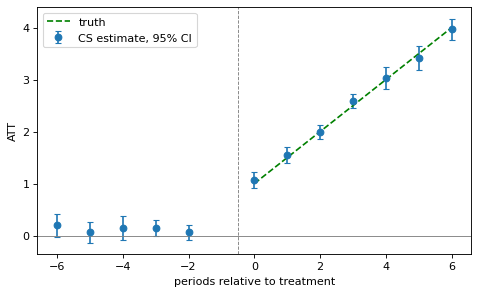

In [9]:
dyn_sim = sp.aggte(cs_sim, type="dynamic")
es = dyn_sim.detail

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(es["relative_time"], es["att"], yerr=1.96 * es["se"], fmt="o", capsize=3, label="CS estimate, 95% CI")
post = es["relative_time"] >= 0
ax.plot(es.loc[post, "relative_time"], 1.0 + 0.5 * es.loc[post, "relative_time"], "g--", label="truth")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(-0.5, color="grey", ls="--", lw=0.8)
ax.set_xlabel("periods relative to treatment")
ax.set_ylabel("ATT")
ax.legend()
plt.show()

处理前的系数围绕 0 波动，处理后的系数沿着真值那条线上升。事件研究图同时回答了两个问题，平行趋势在处理前是否站得住，以及效应怎样随时间展开。

### 逐点区间与同时置信带

上图的误差线是**逐点**的 95% 区间，每个系数单独看有 95% 的覆盖率。如果要对整条路径下结论，比如「所有处理前系数都不显著」，就需要**同时置信带**，它保证整条真实路径以 95% 的概率落在带内。`sp.uniform_bands` 用 sup-t 方法计算，结果比逐点区间宽。

In [10]:
bands = sp.uniform_bands(dyn_sim)
bands[["relative_time", "att", "ci_lower", "ci_upper", "cband_lower", "cband_upper"]].round(3)

,relative_time,att,ci_lower,ci_upper,cband_lower,cband_upper
0,-6,0.194,-0.033,0.420,-0.129,0.517
1,-5,0.065,-0.135,0.266,-0.221,0.352
2,-4,0.145,-0.094,0.384,-0.195,0.485
3,-3,0.142,-0.013,0.297,-0.079,0.363
4,-2,0.063,-0.079,0.204,-0.139,0.264
5,0,1.065,0.906,1.224,0.839,1.291
6,1,1.554,1.404,1.704,1.340,1.768
7,2,1.995,1.858,2.132,1.799,2.190
8,3,2.588,2.446,2.731,2.385,2.792
9,4,3.033,2.828,3.238,2.741,3.325


## 7. 真实数据走一遍

现在换到 `sp.datasets.mpdta()`。这是一份 500 个县、2003 到 2007 年的面板，结构仿照 R `did` 包的同名数据。结果变量 `lemp` 是青少年就业人数的对数，`first_treat` 是所在州首次提高最低工资的年份，0 表示样本期内没有提高。

In [11]:
mpdta = sp.datasets.mpdta()
print(mpdta.head().to_string(index=False))
print("\n各处理批次的县数:")
print(mpdta.groupby("first_treat")["countyreal"].nunique().rename("n_counties").to_string())

 countyreal  year     lemp  first_treat  treat
          0  2003 8.162509         2004      0
          0  2004 8.275744         2004      1
          0  2005 8.300953         2004      1
          0  2006 8.079625         2004      1
          0  2007 8.141533         2004      1

各处理批次的县数:
first_treat
0       125
2004    125
2006    125
2007    125


In [12]:
twfe_mp = sp.hdfe_ols("lemp ~ treat | countyreal + year", data=mpdta, cluster="countyreal")
bacon_mp = sp.bacon_decomposition(mpdta, y="lemp", treat="treat", time="year", id="countyreal")

print(f"TWFE 系数 : {twfe_mp.params['treat']:.4f}  (se {twfe_mp.std_errors['treat']:.4f})")
print(f"以已处理县为对照的比较所占权重 : {bacon_mp['already_treated_control_weight_share']:.1%}")
print()
print(bacon_mp["summary"].round(4).to_string(index=False))

TWFE 系数 : -0.0375  (se 0.0058)
以已处理县为对照的比较所占权重 : 26.7%

                    type  n_comparisons  weight  estimate
Later vs Earlier Treated              3  0.2667   -0.0412
Earlier vs Later Treated              3  0.2667   -0.0422
    Treated vs Untreated              3  0.4667   -0.0327


有四分之一以上的权重落在「晚处理对早处理」的比较上。这里三类比较的估计值相差不大，所以 TWFE 没有像模拟数据里那样离谱。但这是事后才知道的，Bacon 分解的用处正是在于让你事先看清楚风险有多大。

下面跑 Callaway-Sant'Anna。`summary()` 会给出总体 ATT、事件研究系数和全部组别-时期 ATT。

In [13]:
cs = sp.callaway_santanna(mpdta, y="lemp", g="first_treat", t="year", i="countyreal")
print(cs.summary())

  Callaway and Sant'Anna (2021)

  ATT:      -0.0330 ***
  Std. Error:  (0.0078)
  [95% CI]:    [-0.0482,  -0.0178]
  P-value:     <0.001

  Identifying assumption: PT-GT-NEV — Parallel trends based on never-treated groups
    comparison group:   never-treated units only
    restricts pre-trends: no

------------------------------------------------------------------------------
  Event Study Coefficients
------------------------------------------------------------------------------
  e =  -4  |     -0.0049  (0.0145) 
  e =  -3  |      0.0099  (0.0109) 
  e =  -2  |      0.0076  (0.0087) 
  e =   0  |     -0.0338  (0.0075) ***
  e =   1  |     -0.0280  (0.0089) ***
  e =   2  |     -0.0455  (0.0148) ***
  e =   3  |     -0.0277  (0.0144) *

------------------------------------------------------------------------------
  Group-Time ATT Estimates
------------------------------------------------------------------------------
 group  time     att     se  ci_lower  ci_upper  pvalue
  2004  2

读这张表有三个要点。

- **总体 ATT 约为 −0.033**。提高最低工资使青少年就业下降约 3.3%，95% 置信区间不含 0。
- **识别假设写在结果里**。「Parallel trends based on never-treated groups」说明对照组只用了从未处理的县。
- **处理前的系数都不显著**。结果对象里还存了一个联合检验，下面把它取出来。

In [14]:
pre = cs.model_info["pretrend_test"]
print(f"事前趋势联合检验: chi2({pre['df']}) = {pre['statistic']:.2f},  p = {pre['pvalue']:.3f}")

事前趋势联合检验: chi2(5) = 3.64,  p = 0.607


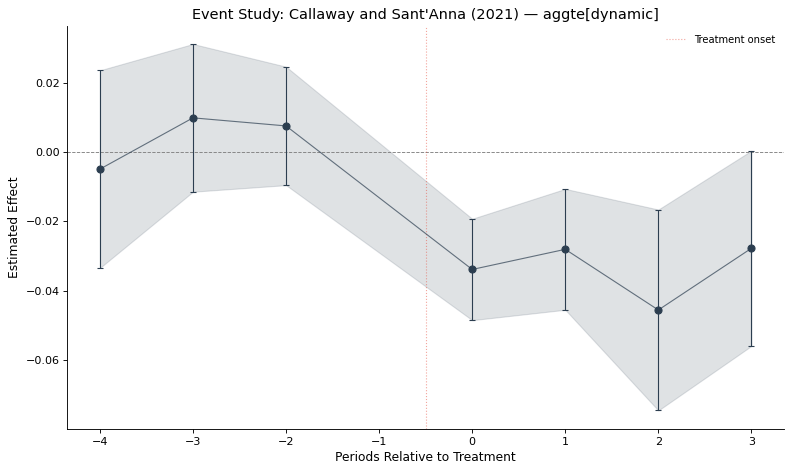

In [15]:
dyn = sp.aggte(cs, type="dynamic")
fig, ax = dyn.plot()
plt.show()

### 对照组怎么选

默认的对照组是从未处理的单位（`control_group="nevertreated"`）。另一个选择是 `"notyettreated"`，把当期尚未处理的单位也纳入对照。后者样本更大、估计更精确，代价是平行趋势假设要对更多的组成立。两者差别大的时候，要回头想哪个假设更可信。

In [16]:
cs_ny = sp.callaway_santanna(
    mpdta, y="lemp", g="first_treat", t="year", i="countyreal",
    control_group="notyettreated",
)
print(f"从未处理为对照 : {cs.estimate:.4f}  (se {cs.se:.4f})")
print(f"尚未处理为对照 : {cs_ny.estimate:.4f}  (se {cs_ny.se:.4f})")

从未处理为对照 : -0.0330  (se 0.0078)
尚未处理为对照 : -0.0323  (se 0.0073)


## 8. 换几个估计量

Callaway-Sant'Anna 不是唯一的修正方案。下面几个估计量出发点不同，但都避开了「用已处理单位当对照」的问题。

| 函数 | 方法 | 思路 |
| --- | --- | --- |
| `sp.sun_abraham` | Sun and Abraham (2021) | 在回归里让每个批次有自己的事件时间系数，再按批次份额加权 |
| `sp.did_imputation` | Borusyak, Jaravel and Spiess (2024) | 只用未处理观测估计固定效应，为已处理观测插补 $Y(0)$ |
| `sp.etwfe` | Wooldridge (2021) | 在 TWFE 里加入批次 × 时期的完全交互 |
| `sp.gardner_did` | Gardner (2022) | 两阶段。先用未处理观测去掉固定效应，再对残差回归 |

把它们放在同一份数据上跑一遍，是一种便宜又有说服力的稳健性检验。

In [17]:
common = dict(y="lemp", group="countyreal", time="year", first_treat="first_treat")

sa = sp.sun_abraham(mpdta, y="lemp", g="first_treat", t="year", i="countyreal")
bjs = sp.did_imputation(mpdta, **common)
etw = sp.etwfe(mpdta, **common)
gar = sp.gardner_did(mpdta, **common)

rows = [
    ("TWFE", twfe_mp.params["treat"], twfe_mp.std_errors["treat"]),
    ("Callaway-Sant'Anna", cs.estimate, cs.se),
    ("Sun-Abraham", sa.estimate, sa.se),
    ("BJS imputation", bjs.estimate, bjs.se),
    ("ETWFE", etw.estimate, etw.se),
    ("Gardner two-stage", gar.estimate, gar.se),
]
compare = pd.DataFrame(rows, columns=["estimator", "att", "se"])
compare["ci_lower"] = compare["att"] - 1.96 * compare["se"]
compare["ci_upper"] = compare["att"] + 1.96 * compare["se"]
compare.round(4)

,estimator,att,se,ci_lower,ci_upper
0,TWFE,-0.0375,0.0058,-0.0488,-0.0262
1,Callaway-Sant'Anna,-0.0330,0.0078,-0.0482,-0.0178
2,Sun-Abraham,-0.0338,0.0090,-0.0515,-0.0161
3,BJS imputation,-0.0351,0.0069,-0.0486,-0.0216
4,ETWFE,-0.0351,0.0069,-0.0487,-0.0215
5,Gardner two-stage,-0.0351,0.0069,-0.0486,-0.0216


几个估计量都落在 −0.03 到 −0.035 之间，结论一致。它们之间的小差别来自对照组和加权方式的不同，例如插补法和 ETWFE 默认把尚未处理的观测也用作对照。

在模拟数据上做同样的对比更能说明问题，因为那里有真值。

In [18]:
common_sim = dict(y="y", group="id", time="t", first_treat="g")
rows = [
    ("TWFE", twfe.params["d"]),
    ("Callaway-Sant'Anna", cs_sim.estimate),
    ("Sun-Abraham", sp.sun_abraham(sim, y="y", g="g", t="t", i="id").estimate),
    ("BJS imputation", sp.did_imputation(sim, **common_sim).estimate),
    ("ETWFE", sp.etwfe(sim, **common_sim).estimate),
    ("Gardner two-stage", sp.gardner_did(sim, **common_sim).estimate),
]
check = pd.DataFrame(rows, columns=["estimator", "att"])
check["att_minus_truth"] = check["att"] - true_att
print(f"真实 ATT = {true_att:.3f}")
check.round(3)

真实 ATT = 2.256


,estimator,att,att_minus_truth
0,TWFE,1.415,-0.841
1,Callaway-Sant'Anna,2.284,0.028
2,Sun-Abraham,2.517,0.261
3,BJS imputation,2.226,-0.030
4,ETWFE,2.226,-0.030
5,Gardner two-stage,2.226,-0.030


TWFE 偏了 0.84，其余估计量里有四个落在真值 0.03 以内。

Sun-Abraham 那一行需要单独解释。它的总体数字是处理后各期事件研究系数的**等权平均**，目标量是 $\frac{1}{7}\sum_{e=0}^{6}(1 + 0.5e) = 2.5$，不是按观测数加权的 2.256。所以 2.517 离它自己的目标只差 0.017，并没有偏。这正好呼应第 5 节的提醒，比较不同估计量的「总体 ATT」之前，先确认它们汇总的是同一个量。

## 9. 平行趋势的敏感性分析

事前趋势检验不显著，并不等于平行趋势成立。检验的功效可能很低，而且处理前平行也不保证处理后继续平行。Rambachan and Roth (2023) 提出换一个问法。

> 如果处理后对平行趋势的偏离不超过某个幅度 $M$，结论还成立吗？

`sp.honest_did` 对一系列 $M$ 给出稳健置信区间。默认的 `method="smoothness"` 限制的是趋势差异的**斜率变化**，$M = 0$ 表示允许两组之间存在线性的趋势差异，$M$ 越大允许的弯曲越多。下面看处理当期（`e=0`）的效应。

In [19]:
honest = sp.honest_did(dyn, e=0)
honest.round(4)

,M,ci_lower,ci_upper,rejects_zero
0,0.0000,-0.0546,-0.0214,True
1,0.0037,-0.0566,-0.0129,True
2,0.0075,-0.0582,-0.0017,True
3,0.0112,-0.0601,0.0058,False
4,0.0149,-0.0632,0.0106,False
5,0.0224,-0.0706,0.0181,False


`rejects_zero` 从 `True` 变成 `False` 的那个 $M$ 叫做**临界值**（breakdown value）。这里的含义是，只要相邻两期之间趋势差异的斜率变化不超过约 0.0075 个对数点，「就业下降」的结论就保得住，超过这个幅度就保不住了。

这个数字大还是小，可以拿处理前观察到的斜率变化作参照。

In [20]:
# 处理前事件研究系数的二阶差分，也就是相邻两期斜率的变化。e = -1 是基期，系数为 0
pre_coefs = dyn.detail.query("relative_time < 0").set_index("relative_time")["att"]
pre_coefs.loc[-1] = 0.0
print("处理前系数      :", pre_coefs.sort_index().round(4).to_dict())
print("相邻斜率的变化  :", np.diff(pre_coefs.sort_index().values, n=2).round(4))

处理前系数      : {-4: -0.0049, -3: 0.0099, -2: 0.0076, -1: 0.0}
相邻斜率的变化  : [-0.0171 -0.0052]


处理前相邻斜率的变化在 0.005 到 0.017 之间（其中包含抽样噪声），和临界值 0.0075 是同一个量级。所以这个结论对平行趋势的偏离只有有限的稳健性。把这句话写进论文，比只报告「事前趋势检验 p = 0.61」要诚实得多。

另一种限制方式是 `method="relative_magnitude"`，它要求处理后的偏离不超过处理前观察到的最大偏离的若干倍。完整说明见 `docs/guides/honest_did.md`。

## 10. 小结

做交错 DID 时可以照着下面的顺序走。

1. **先画图**。各处理批次的平均结果随时间的走势，处理时点分布。
2. **跑 Bacon 分解**（`sp.bacon_decomposition`）。看「已处理单位当对照」的比较占多少权重。
3. **用异质性稳健的估计量**（`sp.callaway_santanna`）。写清楚对照组是从未处理还是尚未处理。
4. **明确汇总方式**（`sp.aggte`）。`simple`、`dynamic`、`group`、`calendar` 回答的是不同的问题。
5. **报告事件研究图**，对整条路径下结论时用同时置信带（`sp.uniform_bands`）。
6. **换估计量复核**（`sp.sun_abraham`、`sp.did_imputation`、`sp.etwfe`、`sp.gardner_did`）。
7. **做敏感性分析**（`sp.honest_did`），报告临界值。

想进一步了解，可以读仓库里的这几份指南。

- `docs/guides/choosing_did_estimator.md`，各估计量的适用场景
- `docs/guides/callaway_santanna.md`，协变量、重复截面、bootstrap
- `docs/guides/honest_did.md`，敏感性分析的细节

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`，可以原样贴进论文。

In [21]:
keys = [
    "goodmanbacon2021difference",
    "callaway2021difference",
    "sun2021estimating",
    "borusyak2024revisiting",
    "wooldridge2021two",
    "gardner2022twostage",
    "rambachan2023more",
]
print(sp.bibtex(keys))

@article{goodmanbacon2021difference,
  title={Difference-in-Differences with Variation in Treatment Timing},
  author={Goodman-Bacon, Andrew},
  journal={Journal of Econometrics},
  volume={225},
  number={2},
  pages={254--277},
  year={2021},
  doi={10.1016/j.jeconom.2021.03.014}
}

@article{callaway2021difference,
  title={Difference-in-Differences with Multiple Time Periods},
  author={Callaway, Brantly and Sant'Anna, Pedro H. C.},
  journal={Journal of Econometrics},
  volume={225},
  number={2},
  pages={200--230},
  year={2021},
  publisher={Elsevier},
  doi={10.1016/j.jeconom.2020.12.001}
}

@article{sun2021estimating,
  title={Estimating Dynamic Treatment Effects in Event Studies with Heterogeneous Treatment Effects},
  author={Sun, Liyang and Abraham, Sarah},
  journal={Journal of Econometrics},
  volume={225},
  number={2},
  pages={175--199},
  year={2021},
  publisher={Elsevier},
  doi={10.1016/j.jeconom.2020.09.006}
}

@article{borusyak2024revisiting,
  title={Revisiting 